In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_csv('data.csv')
df.head()

,x,y,Class
0,24.9,15.9,C3
1,25.2,15.0,C1
2,24.6,14.8,C3
3,25.1,13.6,C2
4,25.6,12.5,C1


In [ ]:
# Change the labels into a 0-2 format
for i in range(len(df)):
  if df.loc[i, 'Class'] == 'C1':
    df.loc[i, 'Class'] = 0
  elif df.loc[i, 'Class'] == 'C2':
    df.loc[i, 'Class'] = 1
  elif df.loc[i, 'Class'] == 'C3':
    df.loc[i, 'Class'] = 2

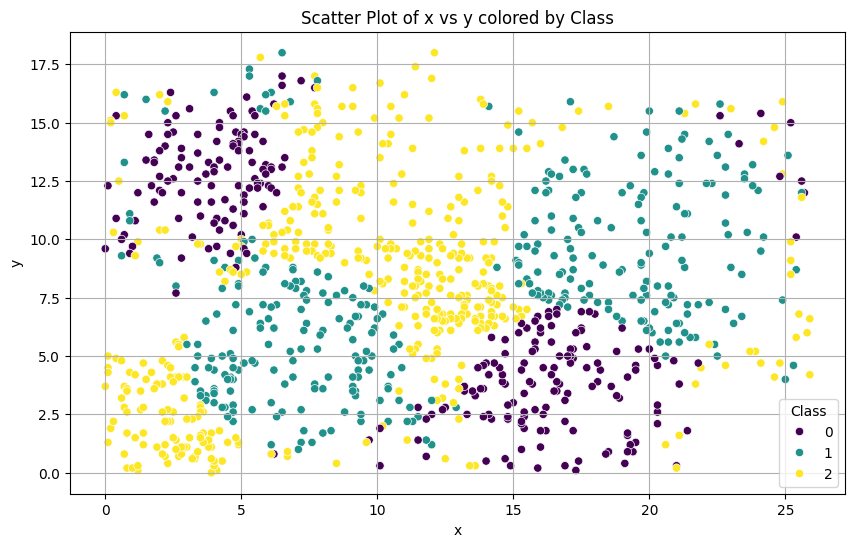

In [ ]:
# visualing the data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='x', y='y', hue='Class', palette='viridis')
plt.title('Scatter Plot of x vs y colored by Class')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

#Building ANN from Scratch

### Testing my functions

In [ ]:
!pip install pytest. # Testing functions


In [ ]:
import math

def sigmod(x):
  return 1/(1 + (math.e ** -x))


assert sigmod(0) == 0.5

In [ ]:
def softmax(z):
    #
    exp_z = np.exp(z - np.max(z))

    return exp_z / np.sum(exp_z)

In [ ]:
weights = np.random.randn(5, 2)
weights

np.dot((10, 40, 2, 45, 20), weights)

array([ 77.75205886, -20.89537347])

In [ ]:
import math
import numpy as np

class ArtificalNeuralNetwork():
  def __init__(self):
    np.random.seed(42) # Added fixed seed for reproducibility
    self.input = 0
    self.label = -1
    self.bias = 1
    self.weights = np.random.randn(2, 5)
    self.weights2 = np.random.randn(5, 3)
    self.last_hidden_activation = 0
    self.learning_rate = 0.001

  def softmax(self, z):
    # Exponentiate each input
    exp_z = np.exp(z - np.max(z))  # Subtracting max for numerical stability
    # Normalize by dividing by the sum
    return exp_z / np.sum(exp_z)

  def sigmod(self, x):
    return 1/(1 + (np.exp(-x)))

  def toHiddenLayer(self):
    # Dot
    dot = np.dot(self.input, self.weights) + self.bias
    first = self.sigmod(dot[0])
    second = self.sigmod(dot[1])
    third = self.sigmod(dot[2])
    fourth = self.sigmod(dot[3])
    fifth = self.sigmod(dot[4])

    return np.array([first, second, third, fourth, fifth])

  def toOutputLayer(self):
    hiddenLayer = self.toHiddenLayer()
    self.last_hidden_activation = hiddenLayer
    dot = np.dot(hiddenLayer, self.weights2) + self.bias
    afterSoftmax = self.softmax(dot)
    return afterSoftmax

  def choosingClass(self):
    afterSoftmax = self.toOutputLayer()
    return np.argmax(afterSoftmax), afterSoftmax


  def backPropagation(self, curr_input, curr_label):

    self.input = curr_input
    choosingClass, values = self.choosingClass()
    y_true = np.zeros(3)
    y_true[curr_label] = 1
    output = values - y_true
    self.weights2 -= self.learning_rate * np.outer(self.last_hidden_activation, output)

    hiddenError = np.dot(self.weights2, output) * self.last_hidden_activation * (1 - self.last_hidden_activation)
    self.weights -= self.learning_rate * np.outer(self.input, hiddenError)





  def training(self, epochs, input, label):
    for i in range(epochs):
      for j in range(len(input)):
        self.backPropagation(input.iloc[j], label[j])

      if i % 10 == 0:
        print(f"Epoch {i}")

  def predict(self, input):
    self.input = input
    return self.choosingClass()

In [ ]:
ann = ArtificalNeuralNetwork()

In [ ]:
df.head()

,x,y,Class
0,24.9,15.9,2
1,25.2,15.0,0
2,24.6,14.8,2
3,25.1,13.6,1
4,25.6,12.5,0


In [ ]:

from sklearn.model_selection import train_test_split
X = df.drop(columns=['Class'])
y = df["Class"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [ ]:
from sklearn.metrics import accuracy_score


# Before training
predictions = []
for n in range(len(X_test)):
  predicted_class, _ = ann.predict(X_test.iloc[n]) # Get predicted class for each sample
  predictions.append(predicted_class)

# Ensure y_test is of a consistent integer type
y_test_int = y_test.astype(int)

# Calculate accuracy once after collecting all predictions
accuracy = accuracy_score(y_test_int, predictions)
print(f"Accuracy on the test set: {accuracy:.4f}")

Accuracy on the test set: 0.3768


In [ ]:
ann.training(1000, X_train, y_train)

Epoch 0
Epoch 10
Epoch 20
Epoch 30
Epoch 40
Epoch 50
Epoch 60
Epoch 70
Epoch 80
Epoch 90
Epoch 100
Epoch 110
Epoch 120
Epoch 130
Epoch 140
Epoch 150
Epoch 160
Epoch 170
Epoch 180
Epoch 190
Epoch 200
Epoch 210
Epoch 220
Epoch 230
Epoch 240
Epoch 250
Epoch 260
Epoch 270
Epoch 280
Epoch 290
Epoch 300
Epoch 310
Epoch 320
Epoch 330
Epoch 340
Epoch 350
Epoch 360
Epoch 370
Epoch 380
Epoch 390
Epoch 400
Epoch 410
Epoch 420
Epoch 430
Epoch 440
Epoch 450
Epoch 460
Epoch 470
Epoch 480
Epoch 490
Epoch 500
Epoch 510
Epoch 520
Epoch 530
Epoch 540
Epoch 550
Epoch 560
Epoch 570
Epoch 580
Epoch 590
Epoch 600
Epoch 610
Epoch 620
Epoch 630
Epoch 640
Epoch 650
Epoch 660
Epoch 670
Epoch 680
Epoch 690
Epoch 700
Epoch 710
Epoch 720
Epoch 730
Epoch 740
Epoch 750
Epoch 760
Epoch 770
Epoch 780
Epoch 790
Epoch 800
Epoch 810
Epoch 820
Epoch 830
Epoch 840
Epoch 850
Epoch 860
Epoch 870
Epoch 880
Epoch 890
Epoch 900
Epoch 910
Epoch 920
Epoch 930
Epoch 940
Epoch 950
Epoch 960
Epoch 970
Epoch 980
Epoch 990


In [ ]:
X_test.iloc[0]

,109
x,21.0
y,6.4


In [ ]:
X_test

,x,y
109,21.0,6.4
76,22.2,7.3
314,7.8,15.6
967,0.1,1.3
616,11.0,8.2
...,...,...
854,8.3,1.8
256,15.4,10.2
110,21.4,1.8
516,13.1,6.8


In [ ]:
ann.predict(X_test.iloc[4])[0]

np.int64(2)

In [ ]:
y_test[5]

2

In [ ]:
pred = ann.predict(X_test.iloc[4])
pred

(np.int64(2), array([0.00641686, 0.42638085, 0.56720229]))

In [ ]:
from sklearn.metrics import accuracy_score

predictions = []
for n in range(len(X_test)):
  predicted_class, _ = ann.predict(X_test.iloc[n]) # Get predicted class for each sample
  predictions.append(predicted_class)

# Ensure y_test is of a consistent integer type
y_test_int = y_test.astype(int)

# Calculate accuracy once after collecting all predictions
accuracy = accuracy_score(y_test_int, predictions)
print(f"Accuracy on the test set: {accuracy:.4f}")

Accuracy on the test set: 0.6135


Report

Before Training, the ANN achieved an accuracy of 37%. This is expect since the model doesn't have any training on the dataset. After training however, the model accurary improved to 61%.

This accurary isn't the best model but it's decent.